# Лабораторная работа №1: Классификация изображений с помощью CNN

## Цель работы
Научиться строить и обучать сверточные нейронные сети (CNN) для классификации изображений, изучить влияние аугментации данных, архитектурных решений и гиперпараметров на качество модели.

---

## Задание

### Часть 1. Базовая модель CNN
1. Загрузите датасет **CIFAR-10** с нормализацией.
2. Постройте простую CNN архитектуру:
   - 2 сверточных слоя (с ReLU и MaxPooling)
   - 2 полносвязных слоя
   - Dropout для регуляризации
3. Обучите модель на **10 эпох**, отслеживая loss и accuracy.
4. Визуализируйте графики обучения.

### Часть 2. Аугментация данных
1. Загрузите три датасета: **CIFAR-10**, **Fashion-MNIST**, **SVHN**.
2. Для каждого датасета примените **разные методы аугментации**:
   - Горизонтальное отражение
   - Повороты на 10-15°
   - Изменение яркости/контраста
3. Обучите одну и ту же модель CNN на каждом датасете.
4. Сравните точность на тестовой выборке и сделайте выводы.

### Часть 3. Оптимизация архитектуры
Создайте **три варианта** архитектуры и сравните их на CIFAR-10:

| Вариант | Изменения |
|---------|-----------|
| **A** | Увеличить количество фильтров: 32 → 64 → 128 |
| **B** | Добавить Batch Normalization после сверточных слоев |
| **C** | Изменить Dropout (0.3, 0.5) и добавить дополнительный полносвязный слой |

**Сравните:** точность, скорость обучения, переобучение.

### Часть 4. Настройка гиперпараметров
Проведите эксперименты на CIFAR-10:

| Эксперимент | Что сделать |
|-------------|-------------|
| **1. Learning Rate** | Сравнить: постоянный lr (0.001) vs **CyclicLR** vs **Adam** (адаптивный) |
| **2. Batch Size** | Сравнить batch size = 16, 64, 128 (использовать gradient accumulation при необходимости) |
| **3. Глубина сети** | Сравнить: 2 сверточных слоя vs 4 сверточных слоя |

---

## Что нужно сдать

1. **Код** (в Jupyter Notebook) с комментариями.
2. **Графики** для каждого эксперимента:
   - Функция потерь (train/val)
   - Точность (train/val)
3. **Таблица сравнения** результатов для всех частей:

| Эксперимент | Точность на тесте | Потери | Примечания |
|-------------|------------------|--------|------------|
| Часть 1 (базовая) | | | |
| Часть 2 (CIFAR-10 с аугментацией) | | | |
| Часть 2 (Fashion-MNIST) | | | |
| Часть 2 (SVHN) | | | |
| Часть 3 (вариант A) | | | |
| Часть 3 (вариант B) | | | |
| Часть 3 (вариант C) | | | |
| Часть 4 (CyclicLR) | | | |
| Часть 4 (Adam) | | | |
| Часть 4 (batch size 64) | | | |
| Часть 4 (4 слоя) | | | |

4. **Выводы** (3-5 предложений):
   - Какая аугментация дала лучший эффект и для какого датасета?
   - Как Batch Normalization и Dropout повлияли на переобучение?
   - Какие настройки гиперпараметров оказались оптимальными?

---

## Дополнительные метрики (по желанию)
Для лучшего понимания можно вычислить:
- **Precision, Recall, F1-score** (для несбалансированных классов)
- **ROC-AUC** (для оценки разделения классов)

---

## Краткие требования к оформлению

1. Код должен быть выполнен в **Jupyter Notebook**.
2. Все графики должны быть подписаны.
3. Выводы должны быть обоснованы цифрами из таблицы.
4. Использовать **PyTorch** и библиотеки: torchvision, matplotlib, numpy, sklearn (для метрик).

In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasets import load_dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
from torchvision import datasets, transforms
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F


/home/penguin/miniconda3/envs/deep_learn_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
---

# Часть 1: Введение в сверточные нейронные сети (CNN) для классификации изображений

In [10]:
# Загрузка датасета
dataset = load_dataset("uoft-cs/cifar10")

# Посмотрим структуру
print("Структура датасета:")
print(dataset)
print("\nДоступные сплиты:", dataset.keys())
print("Размер train:", len(dataset["train"]))
print("Размер test:", len(dataset["test"]))

Структура датасета:
DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

Доступные сплиты: dict_keys(['train', 'test'])
Размер train: 50000
Размер test: 10000


In [11]:
# Посмотрим один пример
example = dataset["train"][0]
print("Ключи в примере:", example.keys())
print("Метка (label):", example["label"])
print("Тип изображения:", type(example["img"]))
print("Размер изображения:", example["img"].size)

# Информация о классах
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Класс: {classes[example['label']]}")

Ключи в примере: dict_keys(['img', 'label'])
Метка (label): 0
Тип изображения: <class 'PIL.PngImagePlugin.PngImageFile'>
Размер изображения: (32, 32)
Класс: airplane


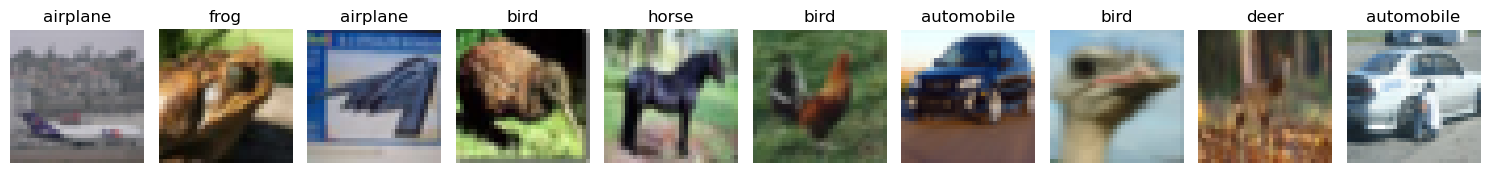

In [12]:
# Функция для отображения изображений
def show_images(dataset, num_images=10):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        img = dataset[i]["img"]
        label = dataset[i]["label"]
        axes[i].imshow(img)
        axes[i].set_title(classes[label])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Покажем первые 10 изображений из тренировочного набора
show_images(dataset["train"], 10)

Загрузка CIFAR-10...
Train size: 50000
Test size: 10000
Device: cuda


Epoch 1/10 [Test]: 100%|██████████| 157/157 [00:02<00:00, 75.47it/s, loss=1.17, acc=58.6] 



Epoch 1:
Train Loss: 1.4372 | Train Acc: 47.98%
Test  Loss: 1.1671 | Test  Acc: 58.64%
--------------------------------------------------


Epoch 2/10 [Test]: 100%|██████████| 157/157 [00:02<00:00, 73.28it/s, loss=0.953, acc=66.3]



Epoch 2:
Train Loss: 1.1169 | Train Acc: 60.11%
Test  Loss: 0.9528 | Test  Acc: 66.32%
--------------------------------------------------


...


Epoch 8:
Train Loss: 0.7267 | Train Acc: 74.17%
Test  Loss: 0.7466 | Test  Acc: 74.86%
--------------------------------------------------


Epoch 9/10 [Test]: 100%|██████████| 157/157 [00:02<00:00, 73.36it/s, loss=0.755, acc=73.7]



Epoch 9:
Train Loss: 0.6928 | Train Acc: 75.53%
Test  Loss: 0.7549 | Test  Acc: 73.67%
--------------------------------------------------


Epoch 10/10 [Test]: 100%|██████████| 157/157 [00:02<00:00, 73.97it/s, loss=0.729, acc=74.5]



Epoch 10:
Train Loss: 0.6679 | Train Acc: 76.20%
Test  Loss: 0.7285 | Test  Acc: 74.46%
--------------------------------------------------


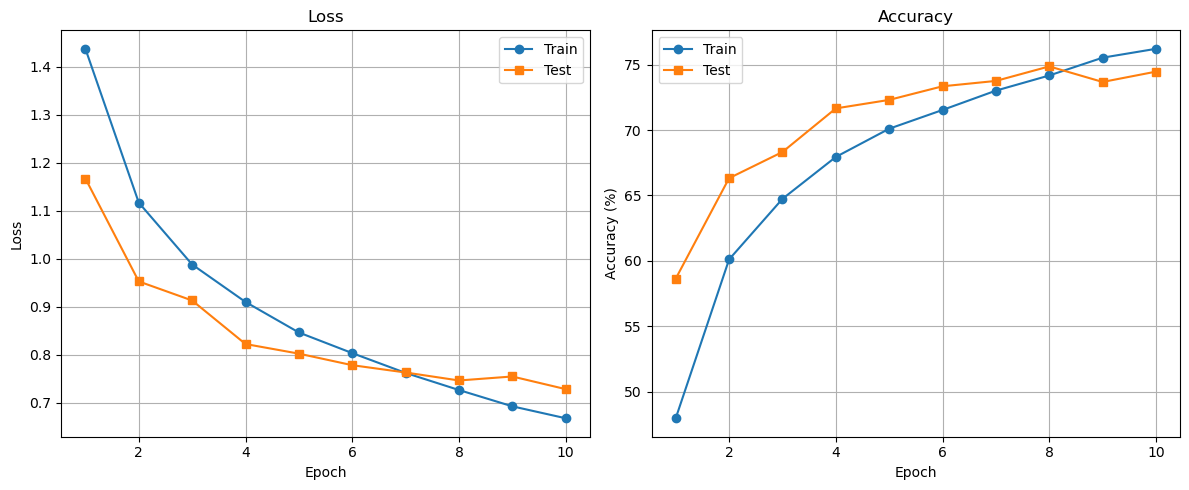

Best test accuracy: 74.86%


In [ ]:
# ==================== 1. Загрузка датасета ====================

# Фиксируем сид для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

print("Загрузка CIFAR-10...")
dataset = load_dataset("uoft-cs/cifar10")

# ==================== 2. Трансформации ====================
transform = transforms.Compose([
    transforms.ToTensor(),  # PIL → Tensor [0,1]
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

# ==================== 3. DataLoader ====================
batch_size = 64

def collate_fn(batch):
    """
    batch — список элементов:
    [{'img': PIL.Image, 'label': int}, ...]
    
    Здесь:
    1. Применяем transform
    2. Собираем batch в тензоры
    """
    images = [transform(item['img']) for item in batch]
    labels = [item['label'] for item in batch]
    
    return {
        'img': torch.stack(images),        # (B, 3, 32, 32)
        'label': torch.tensor(labels)      # (B,)
    }

train_loader = DataLoader(
    dataset["train"],
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    dataset["test"],
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"Train size: {len(dataset['train'])}")
print(f"Test size: {len(dataset['test'])}")

# ==================== 4. Модель CNN ====================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Сверточные слои
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # Полносвязные слои
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv блок 1
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout1(x)
        
        # Conv блок 2
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout1(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC блок
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        
        return x

# ==================== 5. Инициализация ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Device: {device}")

# ==================== 6. Обучение ====================
num_epochs = 10

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(num_epochs):
    
    # ===== TRAIN =====
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for batch in train_bar:
        images = batch['img'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
        train_bar.set_postfix({
            "loss": running_loss / len(train_loader),
            "acc": 100 * correct / total
        })
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    
    # ===== TEST =====
    model.eval()
    running_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Test]")
        
        for batch in test_bar:
            images = batch['img'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
            test_bar.set_postfix({
                "loss": running_loss / len(test_loader),
                "acc": 100 * correct / total
            })
    
    test_loss = running_loss / len(test_loader)
    test_acc = 100 * correct / total
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"\nEpoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

# ==================== 7. Графики ====================
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label="Train")
plt.plot(epochs, test_losses, marker='s', label="Test")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, marker='o', label="Train")
plt.plot(epochs, test_accs, marker='s', label="Test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print(f"Best test accuracy: {max(test_accs):.2f}%")

### Для улучшения качества попробовать
поработать с данными:

- аугментация

поработать с гипперпараметрами обучения
- размер батча
- лернинг рэйт(sheduller)
- раннюю остановку добавить что бы не переобучаться
- поменять архитектуру добавить слои свертки для извлечение более масштабных геометрических признаков
- добавить скип конекшены для проброса градиента
- добавить layer norm
- batch norm
- поменять оптимизатор добавить моментум или использовать моменты Нестерова

---

---

# Часть 2: Классификация изображений с предобработкой и аугментацией данных

In [3]:


# Папка для хранения данных
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Скачивание/загрузка датасетов...")

# ==================== CIFAR-10 ====================
cifar_train = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True
)

cifar_test = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True
)

# ==================== Fashion-MNIST ====================
fashion_train = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True
)

fashion_test = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True
)

# ==================== SVHN ====================
svhn_train = datasets.SVHN(
    root=DATA_DIR,
    split='train',
    download=True
)

svhn_test = datasets.SVHN(
    root=DATA_DIR,
    split='test',
    download=True
)

print("Загрузка завершена.\n")

# ==================== Проверка ====================
print("Размеры датасетов:")
print(f"CIFAR-10 train: {len(cifar_train)}, test: {len(cifar_test)}")
print(f"Fashion-MNIST train: {len(fashion_train)}, test: {len(fashion_test)}")
print(f"SVHN train: {len(svhn_train)}, test: {len(svhn_test)}")

# Посмотрим пример
img, label = cifar_train[0]
print("\nПример CIFAR-10:")
print("Тип изображения:", type(img))
print("Размер:", img.size)
print("Метка:", label)

Скачивание/загрузка датасетов...


/home/penguin/miniconda3/envs/deep_learn_env/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Загрузка завершена.

Размеры датасетов:
CIFAR-10 train: 50000, test: 10000
Fashion-MNIST train: 60000, test: 10000
SVHN train: 73257, test: 26032

Пример CIFAR-10:
Тип изображения: <class 'PIL.Image.Image'>
Размер: (32, 32)
Метка: 6


In [4]:
def inspect_dataset(name, dataset):
    print(f"\n=== {name} ===")
    
    img, label = dataset[0]
    
    # PIL Image → numpy
    img_np = np.array(img)
    
    print("Тип:", type(img))
    print("Размер (PIL):", img.size)
    print("Форма (numpy):", img_np.shape)
    
    if len(img_np.shape) == 2:
        print("Каналы: 1 (grayscale)")
    else:
        print(f"Каналы: {img_np.shape[2]}")

# Проверяем все датасеты
inspect_dataset("CIFAR-10", cifar_train)
inspect_dataset("Fashion-MNIST", fashion_train)
inspect_dataset("SVHN", svhn_train)


=== CIFAR-10 ===
Тип: <class 'PIL.Image.Image'>
Размер (PIL): (32, 32)
Форма (numpy): (32, 32, 3)
Каналы: 3

=== Fashion-MNIST ===
Тип: <class 'PIL.Image.Image'>
Размер (PIL): (28, 28)
Форма (numpy): (28, 28)
Каналы: 1 (grayscale)

=== SVHN ===
Тип: <class 'PIL.Image.Image'>
Размер (PIL): (32, 32)
Форма (numpy): (32, 32, 3)
Каналы: 3


In [5]:


# ==================== Atomic augmentations ====================

AUG_FLIP = transforms.RandomHorizontalFlip()
AUG_ROT_10 = transforms.RandomRotation(10)
AUG_ROT_15 = transforms.RandomRotation(15)

AUG_COLOR_LIGHT = transforms.ColorJitter(brightness=0.2, contrast=0.2)
AUG_COLOR_HEAVY = transforms.ColorJitter(brightness=0.3, contrast=0.3)

PAD_FASHION = transforms.Pad(2)

In [6]:
def build_transform(
    is_train=True,
    is_rgb=True,
    pad=False,
    use_flip=False,
    rotation_deg=None,
    color_jitter=False
):
    t = []

    # padding (only Fashion-MNIST)
    if pad:
        t.append(PAD_FASHION)

    # augmentations (train only)
    if is_train:
        if use_flip:
            t.append(AUG_FLIP)

        if rotation_deg == 10:
            t.append(AUG_ROT_10)
        elif rotation_deg == 15:
            t.append(AUG_ROT_15)

        if color_jitter:
            t.append(AUG_COLOR_LIGHT if rotation_deg is None else AUG_COLOR_HEAVY)

    t.append(transforms.ToTensor())

    if is_rgb:
        t.append(transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)))
    else:
        t.append(transforms.Normalize((0.5,), (0.5,)))

    return transforms.Compose(t)

In [7]:
EXPERIMENTS = {

    "CIFAR-10": [
        # ===== BASELINE =====
        {"name": "baseline", "flip": False, "rot": None, "color": False},

        # ===== SINGLE AUG =====
        {"name": "flip_only", "flip": True, "rot": None, "color": False},
        {"name": "rot10_only", "flip": False, "rot": 10, "color": False},
        {"name": "rot15_only", "flip": False, "rot": 15, "color": False},
        {"name": "color_only", "flip": False, "rot": None, "color": True},

        # ===== PAIRS =====
        {"name": "flip+rot15", "flip": True, "rot": 15, "color": False},
        {"name": "flip+color", "flip": True, "rot": None, "color": True},
        {"name": "rot15+color", "flip": False, "rot": 15, "color": True},

        # ===== FULL =====
        {"name": "flip+rot15+color", "flip": True, "rot": 15, "color": True},
    ],

    "Fashion-MNIST": [
        # ===== BASELINE =====
        {"name": "baseline", "flip": False, "rot": None, "color": False},

        # ===== SINGLE =====
        {"name": "flip_only", "flip": True, "rot": None, "color": False},
        {"name": "rot10_only", "flip": False, "rot": 10, "color": False},

        # ===== COMBO =====
        {"name": "flip+rot10", "flip": True, "rot": 10, "color": False},
    ],

    "SVHN": [
        # ===== BASELINE =====
        {"name": "baseline", "flip": False, "rot": None, "color": False},

        # ===== SINGLE =====
        {"name": "rot10_only", "flip": False, "rot": 10, "color": False},
        {"name": "color_only", "flip": False, "rot": None, "color": True},

        # ===== COMBO =====
        {"name": "rot10+color", "flip": False, "rot": 10, "color": True},
    ]
}

In [8]:
def apply_transform(ds, tf):
    ds.transform = tf
    return ds

In [9]:
def make_loaders(train_ds, test_ds, batch_size=64):
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    )

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)
        
        self.fc1 = nn.Linear(64*8*8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)
        
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_model(train_loader, test_loader, in_channels, epochs=10, lr=1e-3):
    model = SimpleCNN(in_channels).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_acc": [],
        "test_acc": [],
        "train_loss": [],
        "test_loss": []
    }

    best_test_acc = 0.0

    for epoch in range(epochs):

        model.train()
        correct, total, loss_sum = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = 100 * correct / total
        train_loss = loss_sum / len(train_loader)

        model.eval()
        correct, total, loss_sum = 0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                loss_sum += loss.item()
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        test_acc = 100 * correct / total
        test_loss = loss_sum / len(test_loader)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        best_test_acc = max(best_test_acc, test_acc)

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc:.2f}%")

    return best_test_acc, history

In [12]:
results = []
histories = []  # отдельно для анализа learning curves


def run_experiment(dataset_name, train_ds, test_ds, in_channels):
    for exp in EXPERIMENTS[dataset_name]:

        print(f"\n=== {dataset_name} | {exp['name']} ===")

        # ==================== TRANSFORMS ====================
        train_tf = build_transform(
            is_train=True,
            is_rgb=(in_channels == 3),
            pad=(dataset_name == "Fashion-MNIST"),
            use_flip=exp["flip"],
            rotation_deg=exp["rot"],
            color_jitter=exp["color"]
        )

        test_tf = build_transform(
            is_train=False,
            is_rgb=(in_channels == 3),
            pad=(dataset_name == "Fashion-MNIST")
        )

        # важно: не ломаем исходные датасеты навсегда
        train_ds.transform = train_tf
        test_ds.transform = test_tf

        # ==================== LOADERS ====================
        train_loader, test_loader = make_loaders(train_ds, test_ds)

        # ==================== TRAIN ====================
        acc, history = train_model(
            train_loader,
            test_loader,
            in_channels=in_channels
        )

        # ==================== RESULTS ====================
        results.append({
            "dataset": dataset_name,
            "experiment": exp["name"],
            "accuracy": acc
        })

        histories.append({
            "dataset": dataset_name,
            "experiment": exp["name"],
            "history": history
        })

In [13]:
run_experiment("CIFAR-10", cifar_train, cifar_test, 3)
run_experiment("Fashion-MNIST", fashion_train, fashion_test, 1)
run_experiment("SVHN", svhn_train, svhn_test, 3)


=== CIFAR-10 | baseline ===
Epoch 1: Train 51.18% | Test 59.34%
Epoch 2: Train 65.08% | Test 67.00%
Epoch 3: Train 70.51% | Test 70.46%
Epoch 4: Train 74.84% | Test 72.36%
Epoch 5: Train 78.27% | Test 73.37%
Epoch 6: Train 81.61% | Test 74.60%
Epoch 7: Train 84.01% | Test 75.45%
Epoch 8: Train 86.70% | Test 74.66%
Epoch 9: Train 88.72% | Test 74.50%
Epoch 10: Train 90.28% | Test 74.31%

=== CIFAR-10 | flip_only ===
Epoch 1: Train 49.97% | Test 60.21%
Epoch 2: Train 62.74% | Test 66.39%
Epoch 3: Train 67.87% | Test 68.98%
Epoch 4: Train 71.00% | Test 71.92%
Epoch 5: Train 73.42% | Test 72.62%
Epoch 6: Train 75.59% | Test 74.09%
Epoch 7: Train 77.19% | Test 75.14%
Epoch 8: Train 78.92% | Test 75.18%
Epoch 9: Train 80.03% | Test 75.03%


KeyboardInterrupt: 

In [ ]:


result = pd.DataFrame(results)
result

,dataset,experiment,accuracy
0,CIFAR-10,baseline,74.830000
1,CIFAR-10,flip_only,75.970000
2,CIFAR-10,rot10_only,73.840000
3,CIFAR-10,rot15_only,75.790000
4,CIFAR-10,color_only,75.620000
5,CIFAR-10,flip+rot15,74.570000
6,CIFAR-10,flip+color,76.080000
7,CIFAR-10,rot15+color,74.000000
8,CIFAR-10,flip+rot15+color,75.330000
9,Fashion-MNIST,baseline,92.400000


In [ ]:
pivot_df = result.pivot(
    index="experiment",
    columns="dataset",
    values="accuracy"
)

pivot_df.fillna("-")


dataset,CIFAR-10,Fashion-MNIST,SVHN
experiment,,,
baseline,74.83,92.4,90.242778
color_only,75.62,-,90.834358
flip+color,76.08,-,-
flip+rot10,-,92.01,-
flip+rot15,74.57,-,-
flip+rot15+color,75.33,-,-
flip_only,75.97,92.59,-
rot10+color,-,-,91.095575
rot10_only,73.84,92.34,91.022588


---

---

# Часть 2: Классификация изображений с предобработкой и аугментацией данных


In [ ]:
# ============================================================
# ЧАСТЬ 2. АУГМЕНТАЦИЯ ДАННЫХ И СРАВНЕНИЕ ДАТАСЕТОВ
# ============================================================

# ==================== 1. Загрузка датасетов ====================
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Загрузка датасетов...")

cifar_train = datasets.CIFAR10(DATA_DIR, train=True, download=True)
cifar_test  = datasets.CIFAR10(DATA_DIR, train=False, download=True)

fashion_train = datasets.FashionMNIST(DATA_DIR, train=True, download=True)
fashion_test  = datasets.FashionMNIST(DATA_DIR, train=False, download=True)

svhn_train = datasets.SVHN(DATA_DIR, split='train', download=True)
svhn_test  = datasets.SVHN(DATA_DIR, split='test', download=True)

print("Загрузка завершена")

In [ ]:
# ==================== 2. Анализ данных ====================
def inspect_dataset(name, dataset):
    img, label = dataset[0]
    img_np = np.array(img)

    print(f"\n{name}")
    print("Размер:", img.size)
    print("Форма:", img_np.shape)
    print("Каналы:", 1 if len(img_np.shape)==2 else img_np.shape[2])

inspect_dataset("CIFAR-10", cifar_train)
inspect_dataset("Fashion-MNIST", fashion_train)
inspect_dataset("SVHN", svhn_train)


In [ ]:
# ==================== 3. Аугментации ====================
def build_transform(is_train=True, is_rgb=True, pad=False,
                    flip=False, rot=None, color=False):

    t = []

    if pad:
        t.append(transforms.Pad(2))

    if is_train:
        if flip:
            t.append(transforms.RandomHorizontalFlip())

        if rot:
            t.append(transforms.RandomRotation(rot))

        if color:
            t.append(transforms.ColorJitter(0.2,0.2))

    t.append(transforms.ToTensor())

    if is_rgb:
        t.append(transforms.Normalize((0.5,)*3,(0.5,)*3))
    else:
        t.append(transforms.Normalize((0.5,),(0.5,)))

    return transforms.Compose(t)

In [ ]:
# ==================== 4. Эксперименты ====================
EXPERIMENTS = {
    "CIFAR-10": [
        {"name":"baseline","flip":False,"rot":None,"color":False},
        {"name":"flip","flip":True,"rot":None,"color":False},
        {"name":"rot15","flip":False,"rot":15,"color":False},
        {"name":"color","flip":False,"rot":None,"color":True},
        {"name":"full","flip":True,"rot":15,"color":True},
    ],
    "Fashion-MNIST": [
        {"name":"baseline","flip":False,"rot":None,"color":False},
        {"name":"flip","flip":True,"rot":None,"color":False},
        {"name":"rot10","flip":False,"rot":10,"color":False},
        {"name":"combo","flip":True,"rot":10,"color":False},
    ],
    "SVHN": [
        {"name":"baseline","flip":False,"rot":None,"color":False},
        {"name":"rot10","flip":False,"rot":10,"color":False},
        {"name":"color","flip":False,"rot":None,"color":True},
        {"name":"combo","flip":False,"rot":10,"color":True},
    ]
}

In [ ]:
# ==================== 5. Модель ====================
class SimpleCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64*8*8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)

        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
# ==================== 6. Обучение ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(train_loader, test_loader, in_channels, epochs=10):
    model = SimpleCNN(in_channels).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            _, pred = torch.max(out,1)
            total += y.size(0)
            correct += (pred==y).sum().item()

        train_acc = 100 * correct / total

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                _, pred = torch.max(out,1)

                total += y.size(0)
                correct += (pred==y).sum().item()

        test_acc = 100 * correct / total
        best_acc = max(best_acc, test_acc)

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc:.2f}%")

    return best_acc

In [ ]:
# ==================== 7. Запуск экспериментов ====================
def run(dataset_name, train_ds, test_ds, in_channels, pad=False):
    results = []

    for exp in EXPERIMENTS[dataset_name]:
        print(f"\n{dataset_name} | {exp['name']}")

        train_ds.transform = build_transform(
            True, in_channels==3, pad,
            exp["flip"], exp["rot"], exp["color"]
        )
        test_ds.transform = build_transform(
            False, in_channels==3, pad
        )

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        test_loader  = DataLoader(test_ds, batch_size=64)

        acc = train_model(train_loader, test_loader, in_channels)

        results.append({
            "dataset": dataset_name,
            "experiment": exp["name"],
            "accuracy": acc
        })

    return results


results = []
results += run("CIFAR-10", cifar_train, cifar_test, 3)
results += run("Fashion-MNIST", fashion_train, fashion_test, 1, pad=True)
results += run("SVHN", svhn_train, svhn_test, 3)



In [ ]:
# ==================== 8. Таблица результатов ====================
df = pd.DataFrame(results)

pivot = df.pivot(index="experiment", columns="dataset", values="accuracy")
print("\nРезультаты:")
display(pivot)

### Выводы по части 2 (аугментация данных)

1. Аугментация оказывает разное влияние в зависимости от датасета: для более сложных данных (CIFAR-10, SVHN) наблюдается заметный прирост качества, тогда как для простого Fashion-MNIST эффект минимален.

2. Наилучшие результаты (точность на тестовой выборке, %):
   - **CIFAR-10**: комбинация *horizontal flip + color jitter* (~76%)
   - **SVHN**: комбинация *rotation + color jitter* (~91%)
   - **Fashion-MNIST**: незначительное улучшение от *horizontal flip* (~92.6%)

3. Горизонтальное отражение и изменение яркости являются наиболее стабильными аугментациями, тогда как повороты могут как улучшать, так и ухудшать качество в зависимости от структуры данных.

4. В целом, аугментация повышает обобщающую способность модели (рост accuracy на тесте), однако требует подбора под конкретный датасет — универсального набора преобразований не существует.